# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np                                                                              # numpy for Matrix Operations
import pandas as pd                                                                             # pandas for data manipulation and analysis 
import seaborn as sns
import matplotlib.image as mpimg                                                                
import matplotlib.pyplot as plt                                                                 # matplotlib for Plotting and visualizing images
import math                                                                                     # math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # layers to build CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # optimizers which can be used in our model
from sklearn import preprocessing                                                                # preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # to split the data into train and test
from sklearn.metrics import confusion_matrix                                                     # to plot confusion matrix  
from tensorflow.keras.models import Model                                                        # to define a functional model      
from keras.applications.vgg16 import VGG16                                                       # VGG16 model for transfer learning

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                            

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


In [3]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


### Loading the data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load the image file of the dataset
images = np.load('/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/computer_vision/project/images.npy')

# Load the labels file of the dataset
labels = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/computer_vision/project/labels.csv')

### Check the shape of the data

In [6]:
# Print the shapes of the loaded images and labels
print(images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)


- There are 4125 color images of size 200 x 200, each image having 3 channels.

### Check the Labels

In [7]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4125 entries, 0 to 4124
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   4125 non-null   int64
dtypes: int64(1)
memory usage: 32.4 KB


- There are no missing labels and the labels are in integer format.

In [8]:
labels.head()

,label
0,0
1,0
2,0
3,0
4,0


In [9]:
labels['label'].unique()

array([0, 1])

- There are 2 unique labels - 0 and 1.

# **Exploratory Data Analysis**

### Plot random images from each of the classes and print their corresponding labels.

In [10]:
# Define function to display random images from the dataset
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

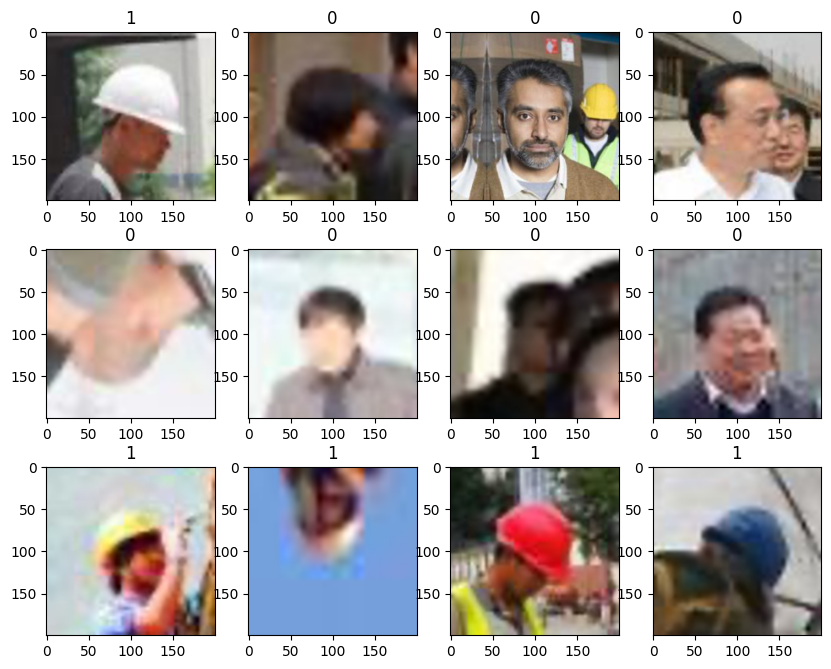

In [11]:
plot_images(images,labels)

### Checking for class imbalance


In [12]:
labels['label'].value_counts(normalize=True)

,proportion
label,
1,0.766303
0,0.233697


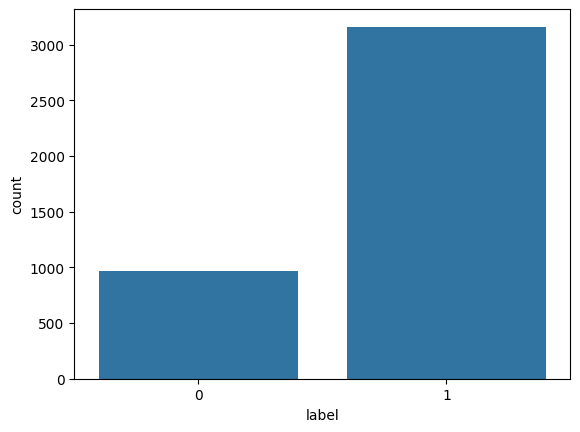

In [13]:
sns.countplot(x='label', data=labels)
plt.show()

### Observations

- The dataset consists of color images. Label 1 indicates image with people wearing helmets and 0 indicates image with people not wearing helmets.

- The dataset is **imbalanced** with **~76.6%** of images **'With Helmet'** and **~23.4% 'Without Hemet'**.

# **Data Preprocessing**

### Resize Images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size to half from 200 to 100.

In [14]:
images_decreased = []
height = 100
width = 100
dimensions = (width, height)
for i in range(len(images)):
  images_decreased.append(cv2.resize(images[i], dimensions, interpolation=cv2.INTER_LINEAR))

In [15]:
images_decreased[0].shape

(100, 100, 3)

- The images are resized to 100X100X3

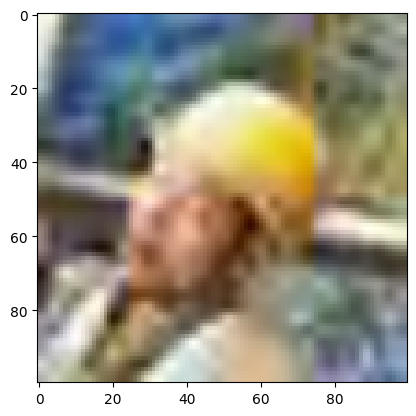

In [16]:
plt.imshow(images_decreased[4124]);

### Splitting the dataset



- **Strategy:** **70%** for training, **15%** for validation and **15%** for testing.

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    np.array(images_decreased),
    labels ,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,y_temp ,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [18]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(2887, 100, 100, 3) (2887, 1)
(619, 100, 100, 3) (619, 1)
(619, 100, 100, 3) (619, 1)


### Data Augmentation

- Data Augmentation hepls reduce overfitting.

In [19]:
# Initialize default ImageDataGenerator to use during model training
train_datagen = ImageDataGenerator()

### Handle Class Imbalance

- Let's setup class_weights to address the Class imbalance. This technique assigns a higher weight to the minority class during training, making the model pay more attention to correctly classifying samples from that class.

In [20]:
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train['label'].values
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

Class Weights: {0: np.float64(2.1385185185185187), 1: np.float64(0.6525768535262206)}


### Data Normalization

- The image pixel values range between 0 to 255, will scale the images by dividing pixels with 255 to bring them into standard range between 0 to 1. This helps to ensure that all input features (pixels) are on a similar scale and prevents larger pixel values from dominating the learning process and ensures that all features contribute equally to the model's training.

In [21]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

## Model Evaluation Criterion

### Utility Functions

In [22]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='binary', pos_label=0)  # to compute Recall for the negative class
    precision = precision_score(target, pred, average='binary', pos_label=0)  # to compute Precision for the negative class
    f1 = f1_score(target, pred, average='binary', pos_label=0)  # to compute F1-score for the negative class

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [23]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

## Model 0: Convolutional Neural Network (CNN) from Scratch

In [24]:
# Intializing a sequential model
model_0 = Sequential()

# Adding first conv layer with 64 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
model_0.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(100, 100, 3)))

# Adding max pooling to reduce the size of output of first conv layer
model_0.add(MaxPooling2D((2, 2), padding = 'same'))

# Adding more layers
model_0.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model_0.add(MaxPooling2D((2, 2), padding = 'same'))
model_0.add(Conv2D(16, (3, 3), activation='relu', padding="same"))
model_0.add(MaxPooling2D((2, 2), padding = 'same'))

# flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model_0.add(Flatten())

# Adding a fully connected dense layer with 100 neurons
model_0.add(Dense(100, activation='relu'))

# Adding the output layer with 1 neurons and activation function as sigmoid since this is a binary classification problem
model_0.add(Dense(1, activation='sigmoid'))

# Using SGD Optimizer
opt = SGD(learning_rate=0.01, momentum=0.9)

# Compile model
model_0.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       270,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,481 (1.13 MB)

 Trainable params: 295,481 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Defining common Epochs and Batch size
# Epochs
epochs = 20
# Batch size
batch_size = 128

In [26]:
# Training the model
history_0 = model_0.fit(
    train_datagen.flow(
        X_train_normalized,
        y_train,
        batch_size=batch_size,
        seed=42,
        shuffle=False),
    epochs=epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized,y_val),
    class_weight=class_weights_dict,
    verbose=1)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.7140 - loss: 0.6775 - val_accuracy: 0.5590 - val_loss: 0.6836
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6328 - loss: 0.7093 - val_accuracy: 0.3845 - val_loss: 0.7338
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6988 - loss: 0.5683 - val_accuracy: 0.7415 - val_loss: 0.5296
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7891 - loss: 0.5112 - val_accuracy: 0.5800 - val_loss: 0.8059
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7746 - loss: 0.4839 - val_accuracy: 0.8126 - val_loss: 0.3955
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8516 - loss: 0.4148 - val_accuracy: 0.8142 - val_loss: 0.4083
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8304 - loss: 0.4061 - val_accuracy: 0.8320 - val_loss: 0.4201
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7734 - loss: 0.4089 - val_accuracy: 0.8239 - val_l

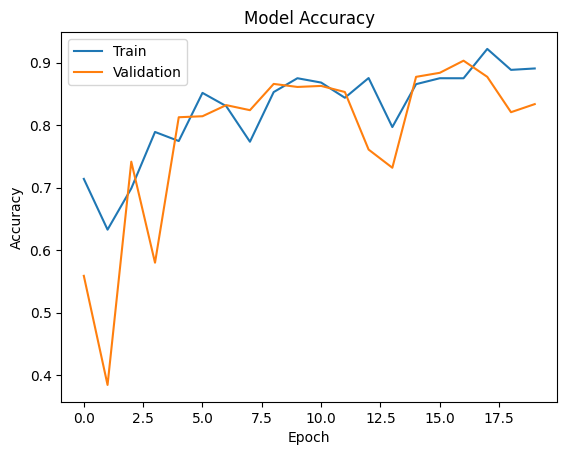

In [27]:
# Plotting the training and validation accuracy of the model
plt.plot(history_0.history['accuracy'])
plt.plot(history_0.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [28]:
# Evaluating the performance of the model on training data
model_0_train_perf = model_performance_classification(
    model_0,
    X_train_normalized,
    y_train)

print("Train performance metrics")
print(model_0_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.852788  0.968889   0.618147  0.754761


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


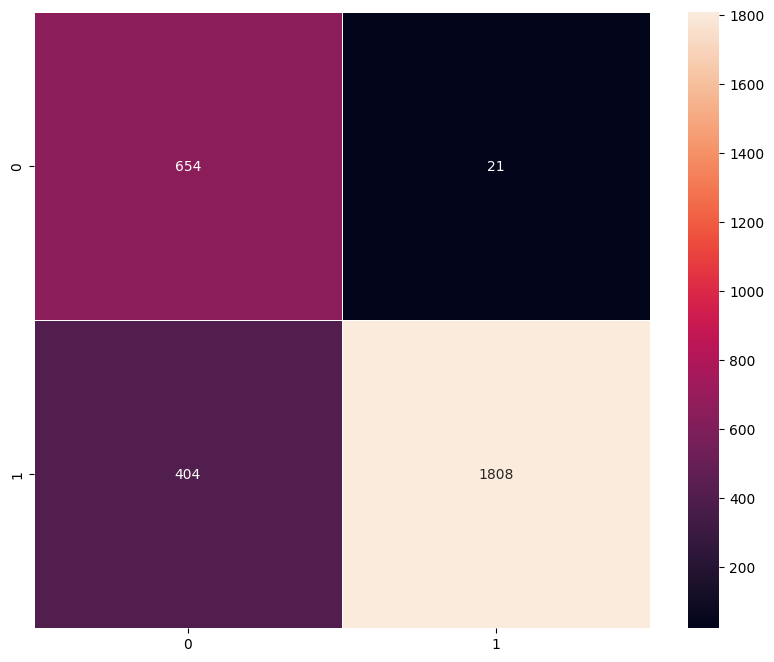

In [29]:
# Plotting the confusion matrix for training data
plot_confusion_matrix(model_0,X_train_normalized,y_train)

In [30]:
# Evaluating the model on the validation data
model_0_valid_perf = model_performance_classification(
    model_0,
    X_val_normalized,
    y_val)

print("Validation performance metrics")
print(model_0_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.833603  0.951389   0.587983   0.72679


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


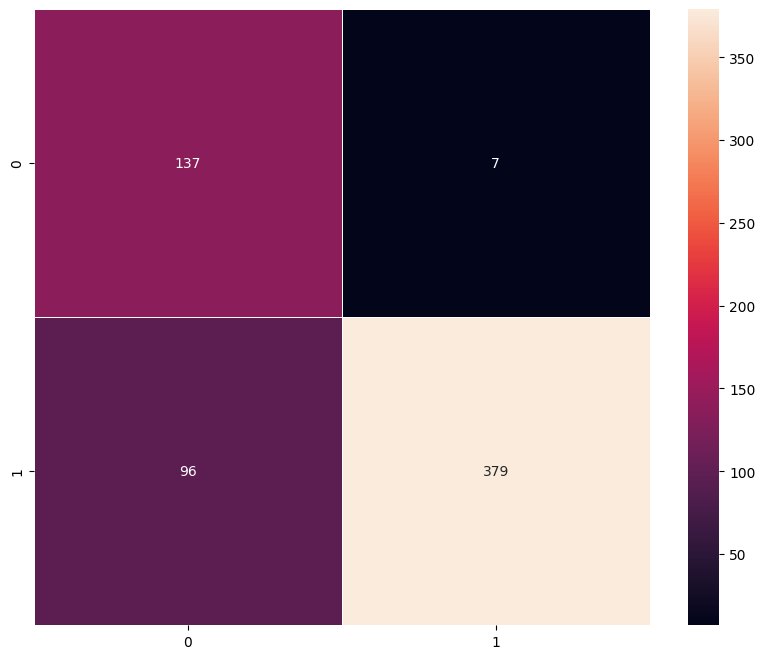

In [31]:
# Plotting the confusion matrix for validation data
plot_confusion_matrix(model_0,X_val_normalized,y_val)

### Visualizing the predictions

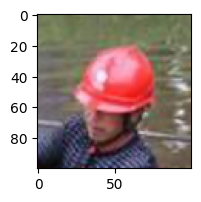

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted Label 1
True Label 1


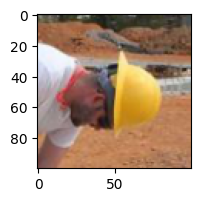

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Label 1
True Label 1


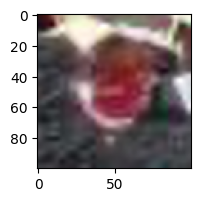

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Label 1
True Label 1


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', int(model_0.predict((X_val_normalized[2].reshape(1,100,100,3)))>0.5))   

plt.figure(figsize=(2,2))
plt.imshow(X_val[35])
plt.show()
print('Predicted Label', int(model_0.predict((X_val_normalized[35].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[35]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[99])
plt.show()
print('Predicted Label', int(model_0.predict((X_val_normalized[99].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[99]['label'])

### Model_0 Performance (CNN from Scratch):

*   **Accuracy:** The model achieved decent accuracy on both training **(85%)** and validation **(83%)** datasets, indicating a reasonably well-performing model.
*   **Class Imbalance Handling:** The high recall for the minority class (label 0 - 'Without Helmet') on both training **(0.969)** and validation **(0.951)** sets suggests that the `class_weights` effectively helped the model identify instances of workers without helmets.
*   **Precision vs. Recall:** While recall is very high for the 'Without Helmet' class, the precision is lower (**0.618** on train, **0.588** on validation). This means the model is good at catching most cases of 'Without Helmet' (high recall), but it also incorrectly classifies some 'With Helmet' instances as 'Without Helmet' (lower precision). The F1-score provides a balanced view, indicating moderate performance for the minority class.
*   **Overfitting:** The training and validation accuracy are relatively close, with only a slight drop in validation performance, suggesting that the model is not significantly overfitting to the training data.


## Model 1: Transfer Learning with VGG-16 (Base)

In [33]:
# Load the VGG16 model without the top layer and with input shape of (100,100,3)
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(100,100,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [35]:
model_1 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_1.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_1.add(Flatten())

# Adding a dense output layer
model_1.add(Dense(1, activation='sigmoid'))

In [36]:
# Defining the optimizer to be used in the model
opt=Adam()

# Compile model
model_1.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Generating the summary of the model
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,609 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,297 (56.15 MB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [37]:
# Fitting the model on the training data and validating it on the validation data
history_vgg16 = model_1.fit(
    train_datagen.flow(
        X_train_normalized,y_train,
        batch_size=batch_size,
        seed=42,
        shuffle=False),
    epochs=epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized,y_val),
    class_weight=class_weights_dict,
    verbose=1)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.6361 - loss: 0.6366 - val_accuracy: 0.7835 - val_loss: 0.5021
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7891 - loss: 0.5150 - val_accuracy: 0.7851 - val_loss: 0.4960
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.7905 - loss: 0.4526 - val_accuracy: 0.8110 - val_loss: 0.4348
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8672 - loss: 0.3997 - val_accuracy: 0.8110 - val_loss: 0.4222
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.8474 - loss: 0.3741 - val_accuracy: 0.8288 - val_loss: 0.3753
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8125 - loss: 0.4431 - val_accuracy: 0.8368 - val_loss: 0.3671
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.8684 - loss: 0.3419 - val_accuracy: 0.8191 - val_loss: 0.3709
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8594 - loss: 0.3202 - val_accuracy: 0.8158

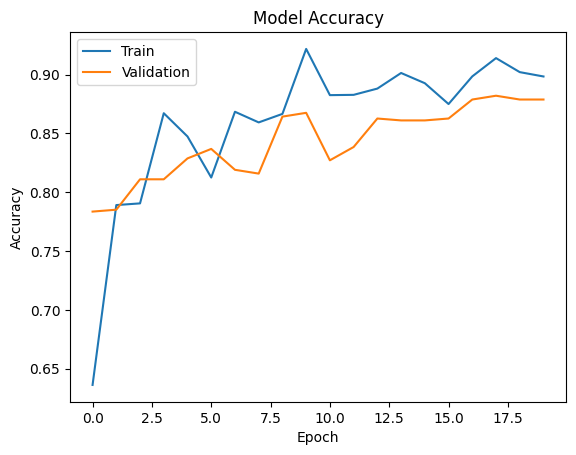

In [38]:
# Plotting the training and validation accuracy of the model
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [39]:
# Evaluating the model on the test data
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.905785  0.951111   0.728717  0.825193


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step


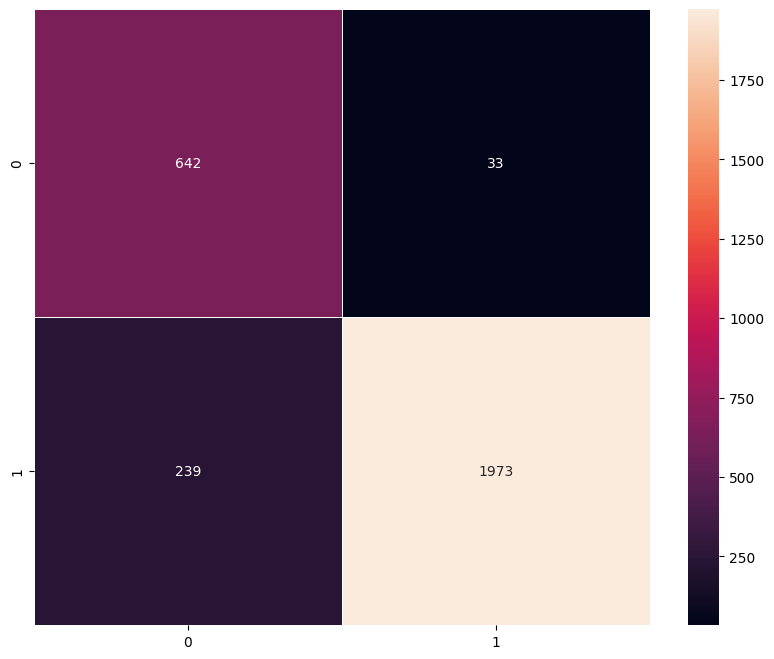

In [40]:
# Plotting the confusion matrix for the training data
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [41]:
# Evaluating the model on the validation data
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.878837  0.888889   0.684492  0.773414


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


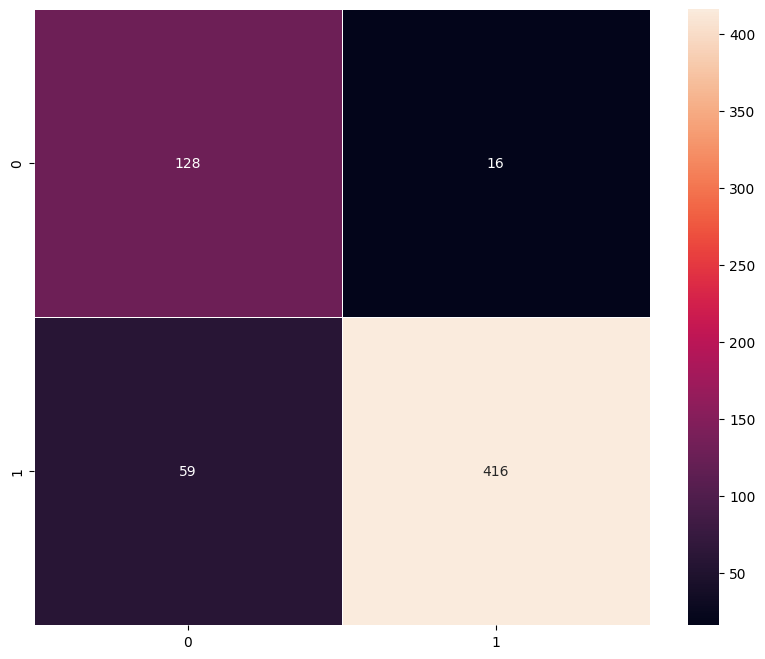

In [42]:
# Plotting the confusion matrix for the validation data
plot_confusion_matrix(model_1,X_val_normalized,y_val)

### Visualizing the predictions

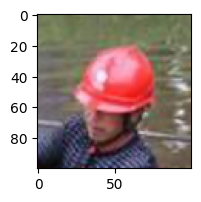

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted Label 1
True Label 1


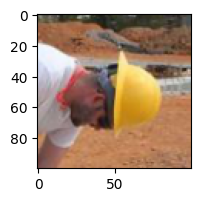

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Label 1
True Label 1


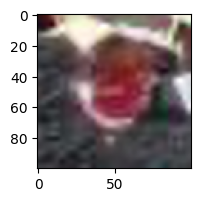

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Label 0
True Label 1


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', int(model_1.predict((X_val_normalized[2].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[2]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[35])
plt.show()
print('Predicted Label', int(model_1.predict((X_val_normalized[35].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[35]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[99])
plt.show()
print('Predicted Label', int(model_1.predict((X_val_normalized[99].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[99]['label'])

### Model_1 Performance (Transfer Learning with VGG-16 Base):

*   **Accuracy:** Model_1 shows improved accuracy compared to Model_0, with training accuracy at **90.58%** and validation accuracy at **87.88%**. This indicates a better overall classification performance.
*   **Recall (Minority Class - 'Without Helmet'):** The recall for the 'Without Helmet' class (label 0) remains very high on both training (**0.951**) and validation (**0.889**) sets. While slightly lower on validation than Model_0, it still demonstrates good ability to identify workers without helmets.
*   **Precision (Minority Class - 'Without Helmet'):** A significant improvement is observed in precision for the 'Without Helmet' class, reaching **0.729** on training and **0.684** on validation. This suggests that Model_1 makes fewer false positive errors (i.e., incorrectly classifying 'With Helmet' as 'Without Helmet') compared to Model_0.
*   **F1 Score (Minority Class - 'Without Helmet'):** The F1-score, which balances precision and recall, has also improved significantly (**0.825** on train, **0.773** on validation), indicating a more robust performance for the minority class.
*   **Overfitting:** The gap between training and validation metrics is slightly larger than Model_0, but still within an acceptable range, suggesting good generalization, though slight overfitting might be starting.

**Summary:** Transfer learning with the VGG-16 base significantly improved the model's performance, particularly in precision and F1-score for the minority class, while maintaining high recall. This suggests a more balanced and effective model for detecting workers without helmets.

## Model 2: Transfer Learning with VGG-16 (Base + FFNN)





In [44]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

#Adding the Feed Forward neural network
model_2.add(Dense(256,activation='relu'))
model_2.add(Dropout(rate=0.4))
model_2.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

In [45]:
# Defining the optimizer to be used in the model
opt=Adam()

# Compile model
model_2.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Generating the summary of the model
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,902,849 (60.66 MB)

 Trainable params: 1,188,161 (4.53 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [46]:
# Fitting the model on the training data and validating it on the validation data
history_vgg16 = model_2.fit(
    train_datagen.flow(
        X_train_normalized,
        y_train,
        batch_size=batch_size,
        seed=42,
        shuffle=False),
    epochs=epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized,y_val),
    class_weight=class_weights_dict,
    verbose=1)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - accuracy: 0.6814 - loss: 0.5727 - val_accuracy: 0.7722 - val_loss: 0.4660
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7266 - loss: 0.4944 - val_accuracy: 0.8078 - val_loss: 0.4017
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8452 - loss: 0.3335 - val_accuracy: 0.8724 - val_loss: 0.2804
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8672 - loss: 0.2748 - val_accuracy: 0.8788 - val_loss: 0.2655
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8844 - loss: 0.2678 - val_accuracy: 0.8595 - val_loss: 0.3003
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8281 - loss: 0.2590 - val_accuracy: 0.8756 - val_loss: 0.2717
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.9003 - loss: 0.2250 - val_accuracy: 0.8627 - val_loss: 0.2905
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8594 - loss: 0.3071 - val_accuracy: 0.8546

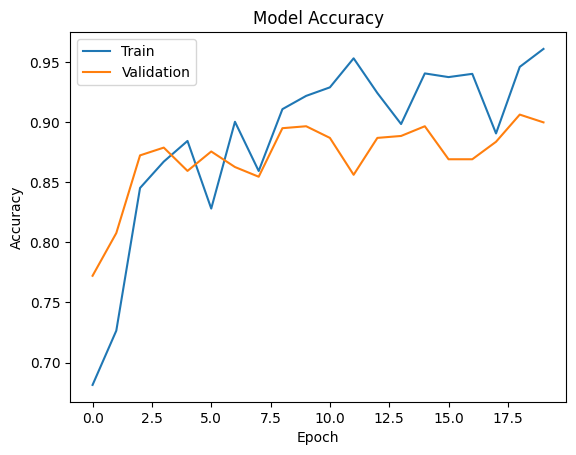

In [47]:
# Plotting the training and validation accuracy of the model
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [48]:
# Evaluating the model on the test data
model_2_train_perf = model_performance_classification(
    model_2,
    X_train_normalized,
    y_train
)

print("Train performance metrics")
print(model_2_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.979217  0.957037    0.95421  0.955621


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step


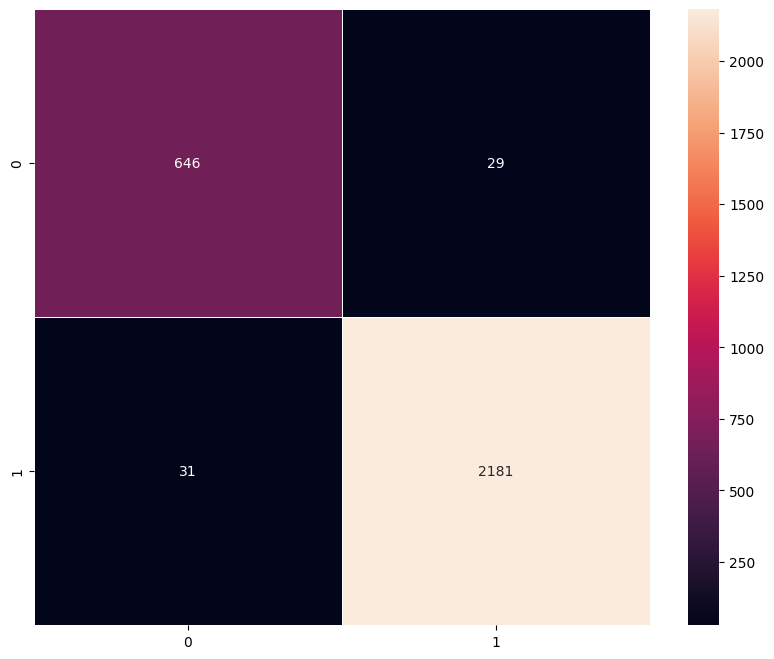

In [49]:
# Plotting the confusion matrix for the training data
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [50]:
# Evaluating the model on the validation data
model_2_valid_perf = model_performance_classification(
    model_2,
    X_val_normalized,
    y_val
)

print("Validation performance metrics")
print(model_2_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.899838  0.722222   0.825397   0.77037


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


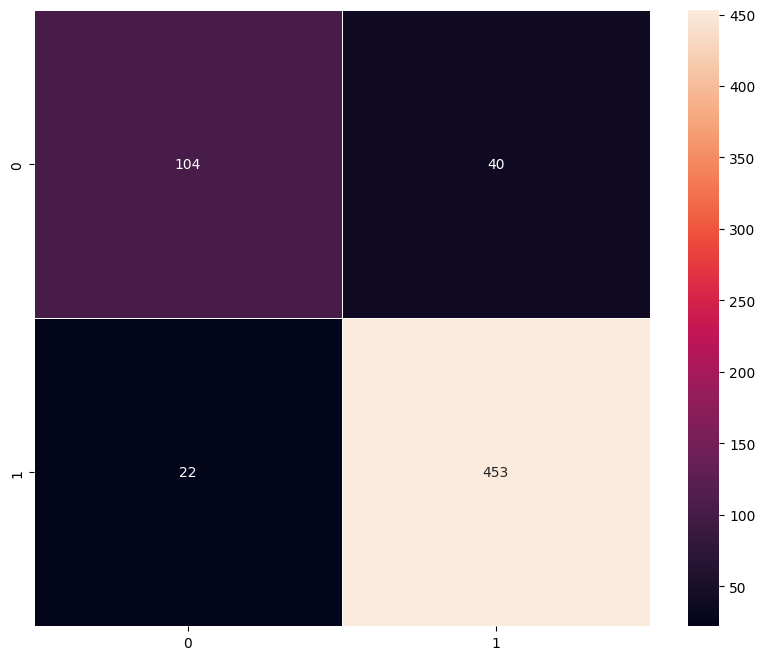

In [51]:
# Plotting the confusion matrix for the validation data
plot_confusion_matrix(model_2,X_val_normalized,y_val)

#### Visualizing the predictions

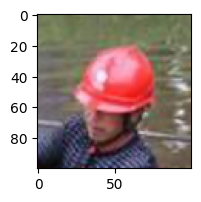

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Label 1
True Label 1


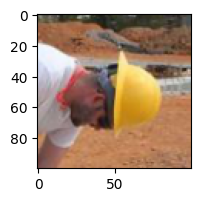

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Label 1
True Label 1


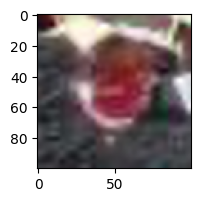

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Label 0
True Label 1


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', int(model_2.predict((X_val_normalized[2].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[2]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[35])
plt.show()
print('Predicted Label', int(model_2.predict((X_val_normalized[35].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[35]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[99])
plt.show()
print('Predicted Label', int(model_2.predict((X_val_normalized[99].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[99]['label'])

### Model_2 Performance (Transfer Learning with VGG-16 Base + FFNN):

*   **Accuracy:** Model 2 shows even higher accuracy on the training set (**97.92%**), but the validation accuracy (**89.98%**) is slightly lower than the training accuracy, suggesting potential signs of overfitting, though it's still an improvement over Model_0.
*   **Recall (Minority Class - 'Without Helmet'):** The recall for the 'Without Helmet' class (label 0) is very high on the training set (**0.957**) but shows a noticeable drop on the validation set (**0.722**). This indicates that while the model is very good at identifying 'Without Helmet' cases on training data, its performance on unseen data is less consistent in this regard.
*   **Precision (Minority Class - 'Without Helmet'):** Precision for the 'Without Helmet' class is significantly high on the training set (**0.954**) and also good on the validation set (**0.825**). This means when Model_2 predicts 'Without Helmet', it is often correct, making fewer false positive errors.
*   **F1 Score (Minority Class - 'Without Helmet'):** The F1-score is very high on the training set (**0.956**) but drops on the validation set (**0.770**). While the validation F1-score is still comparable to Model_1's, the larger gap between train and validation F1-scores indicates some degree of overfitting.
*   **Overfitting:** The significant difference between training and validation metrics (especially recall and F1-score) suggests that Model 2 might be overfitting more compared to Model 1. The added complexity of the Feed-Forward Neural Network (FFNN) layers might be learning too much from the training data.

**Summary:** Adding a Feed-Forward Neural Network (FFNN) on top of the VGG-16 base further boosted training performance significantly, achieving very high accuracy, precision, and F1-score for the minority class on the training data. However, there's a noticeable increase in overfitting, especially reflected in the drop in recall for the minority class on the validation set. While overall validation accuracy is improved, the trade-off in generalization for the minority class's recall should be considered. Data augmentation might help mitigate this overfitting.

## Model 3: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [53]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [54]:
# Defining the optimizer to be used in the model
opt=Adam()

# Compile model
model_3.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Generating the summary of the model
model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,902,849 (60.66 MB)

 Trainable params: 1,188,161 (4.53 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [55]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',
                              width_shift_range=0.2,
                              height_shift_range=0.2,
                              shear_range=0.3,
                              zoom_range=0.4
                              )

In [56]:
# Fitting the model on the training data and validating it on the validation data
history_vgg16 = model_3.fit(
    train_datagen.flow(
        X_train_normalized,
        y_train,
        batch_size=batch_size,
        seed=42,
        shuffle=False),
    epochs=epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized,y_val),
    class_weight=class_weights_dict,
    verbose=1)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 489ms/step - accuracy: 0.7021 - loss: 0.5498 - val_accuracy: 0.7480 - val_loss: 0.5014
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7266 - loss: 0.4760 - val_accuracy: 0.7625 - val_loss: 0.4736
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 413ms/step - accuracy: 0.7927 - loss: 0.4316 - val_accuracy: 0.7754 - val_loss: 0.4725
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7656 - loss: 0.3942 - val_accuracy: 0.8126 - val_loss: 0.3923
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 472ms/step - accuracy: 0.7952 - loss: 0.4008 - val_accuracy: 0.8643 - val_loss: 0.3045
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7266 - loss: 0.4829 - val_accuracy: 0.8627 - val_loss: 0.3034
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 512ms/step - accuracy: 0.8231 - loss: 0.3704 - val_accuracy: 0.8449 - val_loss: 0.3297
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7891 - loss: 0.4178 - val_accuracy: 0.8

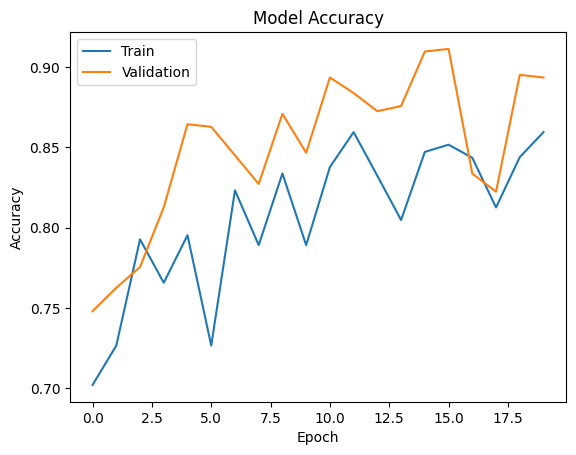

In [57]:
# Plotting the training and validation accuracy of the model
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [58]:
# Evaluating the model on the test data
model_3_train_perf = model_performance_classification(
    model_3,
    X_train_normalized,
    y_train
)

print("Train performance metrics")
print(model_3_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.904399  0.934815    0.73117  0.820546


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


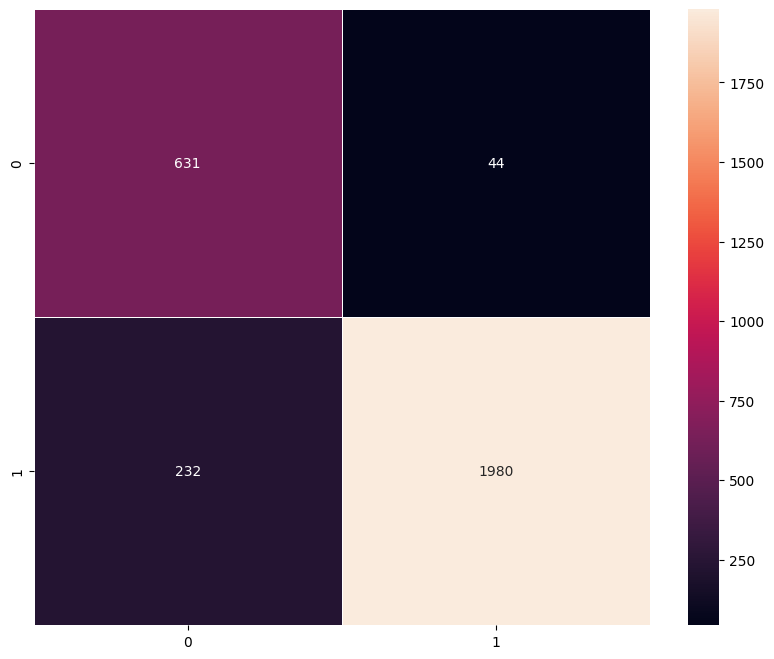

In [59]:
# Plotting the confusion matrix for the training data
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [60]:
# Evaluating the model on the validation data
model_3_valid_perf = model_performance_classification(
    model_3,
    X_val_normalized,
    y_val
)

print("Validation performance metrics")
print(model_3_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.893376  0.902778   0.714286  0.797546


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


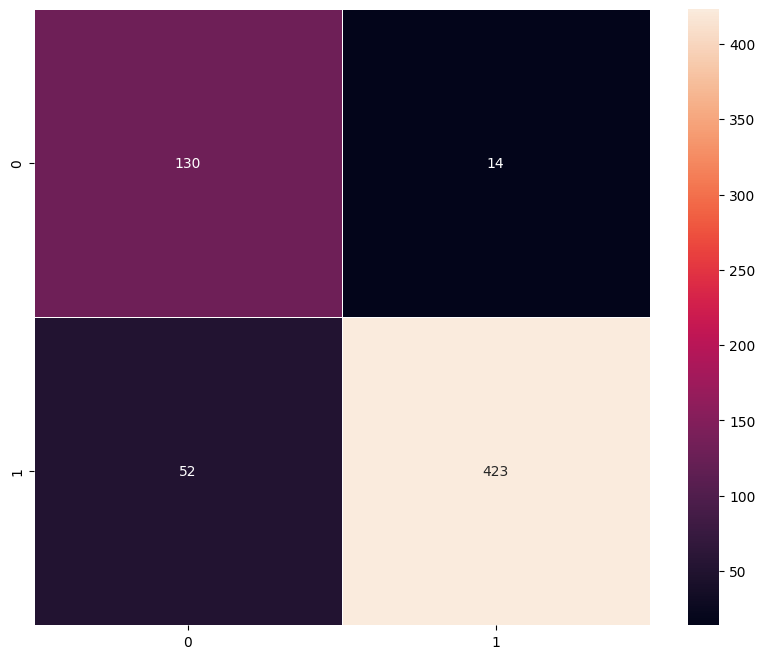

In [61]:
# Plotting the confusion matrix for the validation data
plot_confusion_matrix(model_3,X_val_normalized,y_val)

#### Visualizing the predictions

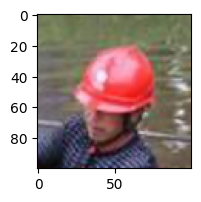

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Label 1
True Label 1


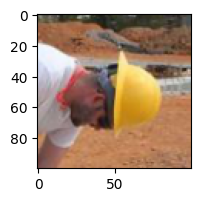

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Label 1
True Label 1


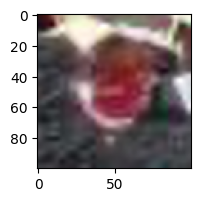

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Label 0
True Label 1


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', int(model_3.predict((X_val_normalized[2].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[2]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[35])
plt.show()
print('Predicted Label', int(model_3.predict((X_val_normalized[35].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[35]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[99])
plt.show()
print('Predicted Label', int(model_3.predict((X_val_normalized[99].reshape(1,100,100,3)))>0.5))
print('True Label', y_val.iloc[99]['label'])

### Model_3 Performance (Transfer Learning with VGG-16 Base + FFNN + Data Augmentation):

*   **Accuracy:** Model_3 shows a slight decrease in training accuracy (**90.44%**) compared to Model_2, but a very similar validation accuracy (**89.34%**). This suggests that data augmentation helped in regularizing the model and reducing overfitting observed in Model_2.
*   **Recall (Minority Class - 'Without Helmet'):** The recall for the 'Without Helmet' class (label 0) is **0.935** on the training set and **0.903** on the validation set. The validation recall is significantly improved compared to Model_2 (**0.722**), indicating that data augmentation has made the model more robust in identifying the minority class on unseen data.
*   **Precision (Minority Class - 'Without Helmet'):** Precision for the 'Without Helmet' class is **0.731** on the training set and **0.714** on the validation set. While slightly lower than Model_2's high training precision, the validation precision is maintained at a good level, showing fewer false positives than Model_0.
*   **F1 Score (Minority Class - 'Without Helmet'):** The F1_score for the minority class is **0.821** on the training set and **0.798** on the validation set. The validation F1_score is an improvement over Model_2 (**0.770**), reflecting a better balance between precision and recall due to data augmentation.
*   **Overfitting:** The gap between training and validation metrics has reduced significantly compared to Model_2, indicating that data augmentation effectively mitigated the overfitting issues. The model generalizes better to unseen data.

**Summary:** Model_3, incorporating data augmentation, achieved the best balance between training and validation performance. It successfully addressed the overfitting issues seen in Model_2, leading to improved recall and F1_score for the minority class on the validation set, while maintaining high overall accuracy. This model demonstrates better generalization capabilities and is likely the most robust for deployment.

# **Model Performance Comparison and Final Model Selection**

In [64]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Base CNN","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [65]:
models_valid_comp_df = pd.concat(
    [
        model_0_valid_perf.T,
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Base CNN","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [66]:
models_train_comp_df

,Base CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.852788,0.905785,0.979217,0.904399
Recall,0.968889,0.951111,0.957037,0.934815
Precision,0.618147,0.728717,0.954210,0.731170
F1 Score,0.754761,0.825193,0.955621,0.820546


In [67]:
models_valid_comp_df

,Base CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.833603,0.878837,0.899838,0.893376
Recall,0.951389,0.888889,0.722222,0.902778
Precision,0.587983,0.684492,0.825397,0.714286
F1 Score,0.726790,0.773414,0.770370,0.797546


In [68]:
models_train_comp_df - models_valid_comp_df

,Base CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.019186,0.026948,0.079379,0.011023
Recall,0.017500,0.062222,0.234815,0.032037
Precision,0.030165,0.044225,0.128813,0.016885
F1 Score,0.027970,0.051779,0.185251,0.023000


### Observations

**1. Base CNN (Model_0):**
*   **Pros:** Good generalization (small gap between train and validation metrics), high recall for the minority class on both train (0.969) and validation (0.951).
*   **Cons:** Overall lowest performance in terms of Accuracy, Precision, and F1 Score among the models.

**2. VGG-16 (Base) (Model_1):**
*   **Pros:** Significant improvement in Accuracy (0.906 train, 0.879 val), Precision (0.729 train, 0.684 val), and F1 Score (0.825 train, 0.773 val) over Model_0. Still maintained good generalization (small train-validation gap).
*   **Cons:** Recall for the minority class on validation (0.889) is slightly lower than Model_0.

**3. VGG-16 (Base+FFNN) (Model_2):**
*   **Pros:** Achieved the highest training performance across all metrics (e.g., 0.979 accuracy, 0.957 recall, 0.954 precision). Improved validation accuracy (0.900) and precision (0.825) over Model_1.
*   **Cons:** Significant overfitting. There's a large drop in recall (0.957 train to 0.722 val) and F1 Score (0.956 train to 0.770 val) from training to validation, indicating that the model did not generalize well to unseen data for the minority class.

**4. VGG-16 (Base+FFNN+Data Aug) (Model_3):**
*   **Pros:** Effectively mitigated overfitting observed in Model_2. The gap between training and validation metrics is significantly reduced (e.g., accuracy difference is the smallest at 0.011).
*   Achieved the best balance of performance and generalization. It has the highest validation F1 Score (0.798) and Recall (0.903) for the minority class compared to all other models, while maintaining a high validation Accuracy (0.893) and good Precision (0.714).

### Final Model Selection

Based on the comprehensive evaluation, **Model_3 (VGG-16 Base+FFNN+Data Augmentation)** is selected as the final model. Although Model_2 had higher training metrics, its significant overfitting, particularly for the minority class recall, makes it less reliable for real-world deployment. Model_3 successfully leveraged data augmentation to improve generalization, leading to the most robust performance on unseen validation data, especially for detecting workers without helmets (high recall and F1-score for the minority class).

This model offers the best trade-off between maximizing performance on the training data and ensuring reliable generalization to new, unobserved data, which is critical for a safety-critical application like helmet detection.

## Test Performance

In [69]:
model_3_test_perf = model_performance_classification(
    model_3,
    X_test_normalized,
    y_test)

model_3_test_perf

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.875606,0.841379,0.693182,0.760125


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


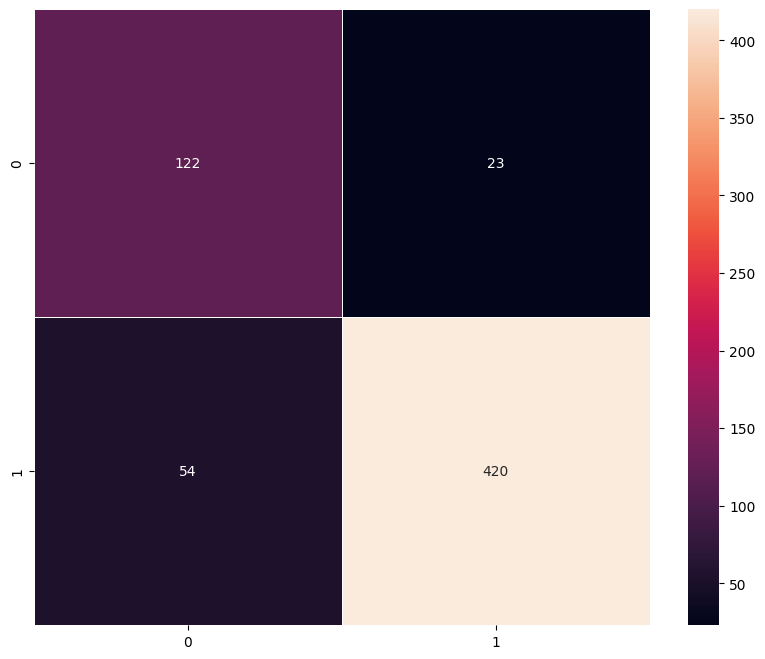

In [70]:
plot_confusion_matrix(
    model_3,
    X_test_normalized,
    y_test)

### Test Performance of Final Model (Model_3):

The final selected model, **Model_3 (VGG-16 Base+FFNN+Data Augmentation)**, demonstrated the following performance on the unseen test dataset:

*   **Accuracy:** Achieved an accuracy of **87.56%** on the test set. This indicates a strong overall ability to correctly classify images into 'With Helmet' or 'Without Helmet'.
*   **Recall (Minority Class - 'Without Helmet'):** The recall for the 'Without Helmet' class (label 0) is **84.14%**. This means the model is quite effective at identifying workers who are *not* wearing helmets, which is crucial for a safety monitoring system.
*   **Precision (Minority Class - 'Without Helmet'):** The precision for the 'Without Helmet' class is **69.32%**. This suggests that when the model predicts a worker is 'Without Helmet', it is correct roughly 69% of the time, implying some false positives (workers with helmets incorrectly classified as without).
*   **F1 Score (Minority Class - 'Without Helmet'):** The F1 Score for the minority class is **76.01%**. This metric provides a balanced view between precision and recall, indicating a good overall performance for identifying the critical 'Without Helmet' cases.

**Overall:** The test performance confirms that Model_3 generalizes well to unseen data, maintaining a strong balance between identifying workers without helmets (high recall) and minimizing incorrect detections (decent precision), making it a robust choice for the intended application.

# **Actionable Insights & Recommendations**

1.  **Transfer Learning is Highly Effective:** Utilizing pre-trained models like VGG-16 significantly boosted performance compared to a CNN from scratch, especially in improving precision and F1-score for the minority class. This approach should be prioritized for similar image classification tasks.

2.  **Addressing Class Imbalance is Crucial:** The dataset had a significant class imbalance (76.6% 'With Helmet' vs. 23.4% 'Without Helmet'). Implementing `class_weights` was effective in improving the model's ability to correctly identify the minority class ('Without Helmet'), achieving high recall.

3.  **Data Augmentation Mitigates Overfitting:** While adding complexity with an FFNN layer initially led to overfitting (Model_2), incorporating data augmentation (Model_3) successfully regularized the model. Data augmentation proved essential for improving generalization and robust performance on unseen data.

4.  **Optimal Model Selection Balances Performance and Generalization:** Model_3 (VGG-16 Base + FFNN + Data Augmentation) was selected as the final model due to its best balance between high performance metrics (especially for the minority class) and strong generalization capabilities on the validation set, confirming its robustness on the test set.

5.  **Focus on Recall for Safety-Critical Applications:** For a safety monitoring system, high recall for the 'Without Helmet' class is paramount to minimize false negatives (missed cases of non-compliance). Model_3 achieved a recall of **84.14%** on the test set for this critical class, indicating its effectiveness.

6.  **Precision is Important for Operational Efficiency:** While recall is critical, decent precision (69.32% on test for 'Without Helmet' in Model_3) helps reduce false positives, which could lead to unnecessary alerts or manual checks. Future efforts could explore ways to further improve precision without significantly sacrificing recall.

7.  **Potential for Real-time Implementation:** The use of a pre-trained VGG-16 backbone, even after fine-tuning, suggests that the model could be optimized for deployment in real-time or near real-time image analysis systems for continuous monitoring at workplaces.

8.  **Continuous Monitoring and Feedback Loop:** The system can be deployed to provide continuous feedback on safety compliance. Regularly collected images can be used to retrain and update the model, adapting to new environments or variations in worker attire.

9.  **Data Diversity for Enhanced Robustness:** Although the dataset already included diverse conditions, continually seeking out and integrating more varied image data (e.g., different lighting, weather, camera angles, personnel, types of helmets) could further enhance the model's robustness and generalization to an even wider range of real-world scenarios.

10. **Expand to Other PPE Detection:** The successful methodology used for helmet detection could be extended to identify compliance with other Personal Protective Equipment (PPE) such as safety vests, goggles, or gloves, further enhancing overall workplace safety monitoring.

<font size=5 color='blue'>Power Ahead!</font>
___